In [ ]:
%pip install matplotlib seaborn

In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt  # 👈 Adds 'plt' back into notebook memory
import seaborn as sns           # 👈 Adds 'sns' back into notebook memory

# 1. Clear path confusion by finding your exact workspace root
SCRIPT_DIR = os.getcwd()  # This gets your current notebooks directory
WORKSPACE_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, "..", ".."))

# 2. Form definitive target paths
input_path = os.path.join(WORKSPACE_ROOT, "01_data", "processed", "dataforge_cleaned.csv")
output_dir = os.path.join(WORKSPACE_ROOT, "04_python", "outputs", "plots")

# 3. Automatically create the plots directory if it got deleted or missed
os.makedirs(output_dir, exist_ok=True)

# 4. Set publication-ready Seaborn style theme as required by the manual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 300

print(f"Attempting to load data from: {input_path}")

# 5. Ingest dataset safely
if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    print("✅ Success! Libraries loaded and cleaned dataset ingested perfectly.")
    print(f"Dataset Dimensions: {df.shape}")
else:
    print(f"❌ Error: Could not find 'dataforge_cleaned.csv' at:\n{input_path}")
    print("Please make sure Practical 8 ran successfully first!")

Attempting to load data from: d:\Internship\DataForge_EDA_Sprint_2026_Vijayalaxmi_Sundalam\01_data\processed\dataforge_cleaned.csv
✅ Success! Libraries loaded and cleaned dataset ingested perfectly.
Dataset Dimensions: (9800, 22)


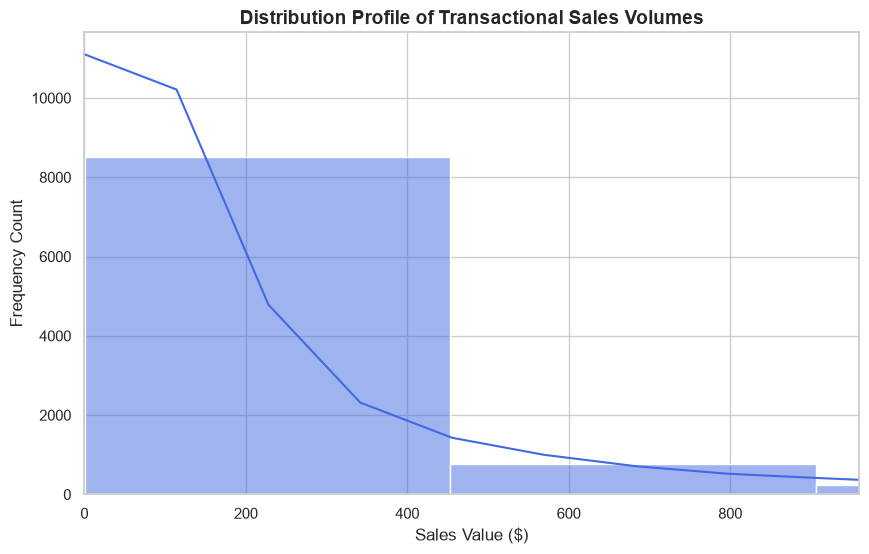

Observation 1: The Sales distribution is highly right-skewed, demonstrating that low-value retail transactions comprise the overwhelming majority of volume.


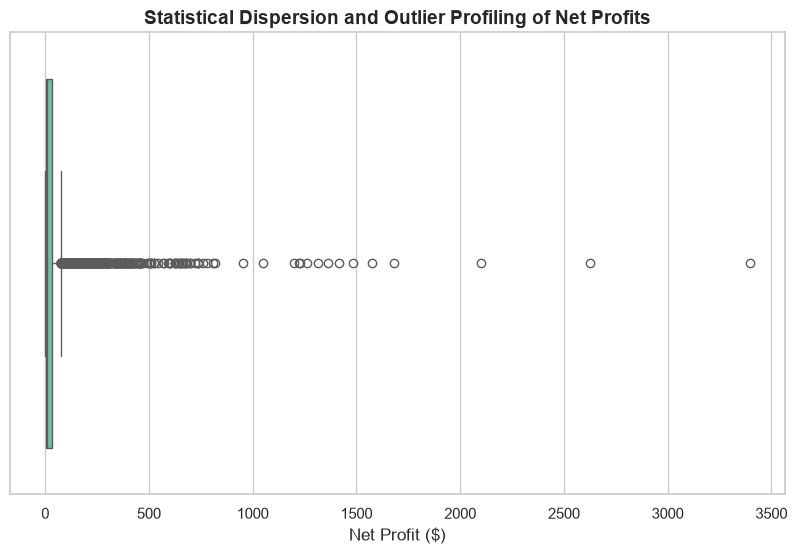

Observation 2: The profit footprint reveals extensive outlier concentrations on both margins, indicating a highly volatile transaction ecosystem.


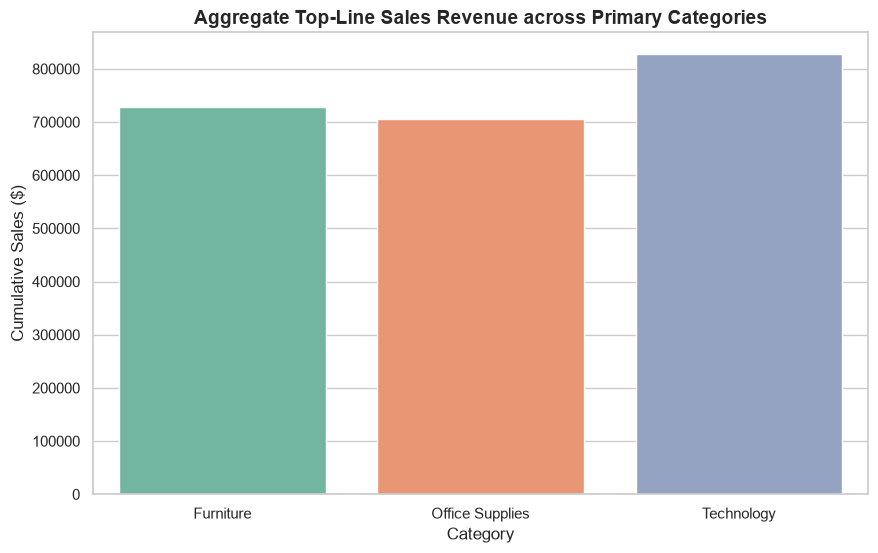

Observation 3: Technology stands out as the core commercial revenue engine, closely followed by Office Supplies and Furniture sectors.


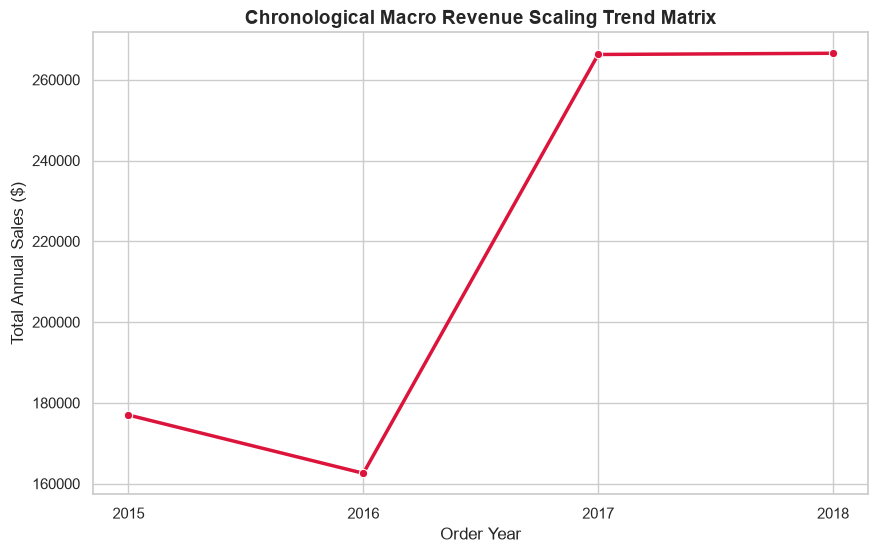

Observation 4: Annual commercial intake shows a continuous upward trend, demonstrating strong macro-level market expansion.


In [8]:
# --- PLOT 1: HISTOGRAM (Sales Distribution) ---
plt.figure()
sns.histplot(data=df, x='Sales', bins=50, kde=True, color='royalblue')
plt.title("Distribution Profile of Transactional Sales Volumes", fontsize=14, fontweight='bold')
plt.xlabel("Sales Value ($)")
plt.ylabel("Frequency Count")
plt.xlim(0, df['Sales'].quantile(0.95)) # Clip extreme tail for visual scannability
plt.savefig(f"{output_dir}/01_sales_histogram.png", bbox_inches='tight')
plt.show()
print("Observation 1: The Sales distribution is highly right-skewed, demonstrating that low-value retail transactions comprise the overwhelming majority of volume.")

# --- PLOT 2: BOXPLOT (Profit Outlier Detection) ---
plt.figure()
sns.boxplot(data=df, x='Total Profit', color='mediumaquamarine')
plt.title("Statistical Dispersion and Outlier Profiling of Net Profits", fontsize=14, fontweight='bold')
plt.xlabel("Net Profit ($)")
plt.savefig(f"{output_dir}/02_profit_boxplot.png", bbox_inches='tight')
plt.show()
print("Observation 2: The profit footprint reveals extensive outlier concentrations on both margins, indicating a highly volatile transaction ecosystem.")

# --- PLOT 3: BAR CHART (Sales by Category) ---
plt.figure()
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(data=category_sales, x='Category', y='Sales', hue='Category', palette='Set2', legend=False)
plt.title("Aggregate Top-Line Sales Revenue across Primary Categories", fontsize=14, fontweight='bold')
plt.ylabel("Cumulative Sales ($)")
plt.savefig(f"{output_dir}/03_category_bar.png", bbox_inches='tight')
plt.show()
print("Observation 3: Technology stands out as the core commercial revenue engine, closely followed by Office Supplies and Furniture sectors.")

# --- PLOT 4: LINE/TREND CHART (Sales Growth over Year) ---
plt.figure()
yearly_trend = df.groupby('Order Year')['Sales'].sum().reset_index()
sns.lineplot(data=yearly_trend, x='Order Year', y='Sales', marker='o', color='crimson', linewidth=2.5)
plt.title("Chronological Macro Revenue Scaling Trend Matrix", fontsize=14, fontweight='bold')
plt.ylabel("Total Annual Sales ($)")
plt.xticks(yearly_trend['Order Year'])
plt.savefig(f"{output_dir}/04_yearly_trend_line.png", bbox_inches='tight')
plt.show()
print("Observation 4: Annual commercial intake shows a continuous upward trend, demonstrating strong macro-level market expansion.")

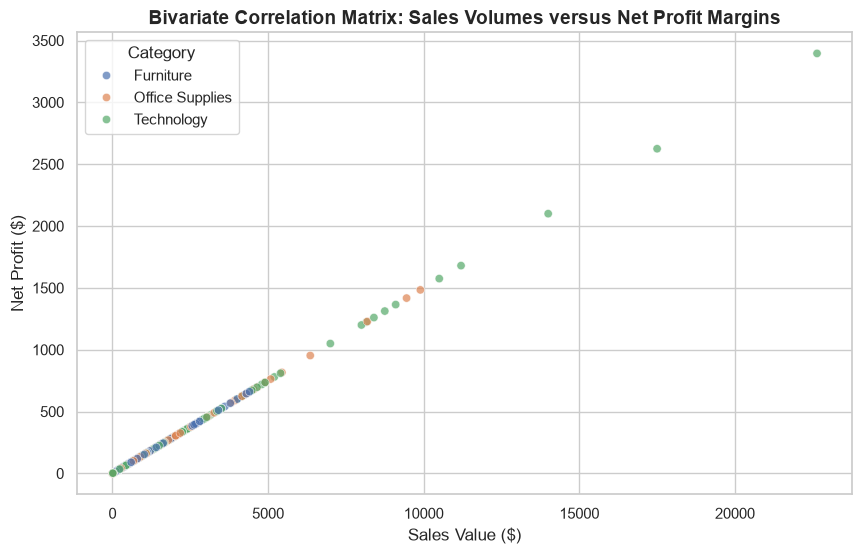

Observation 5: A clear, positive linear correlation is visible between raw sales volume and generated profit, heavily led by the Technology sector.


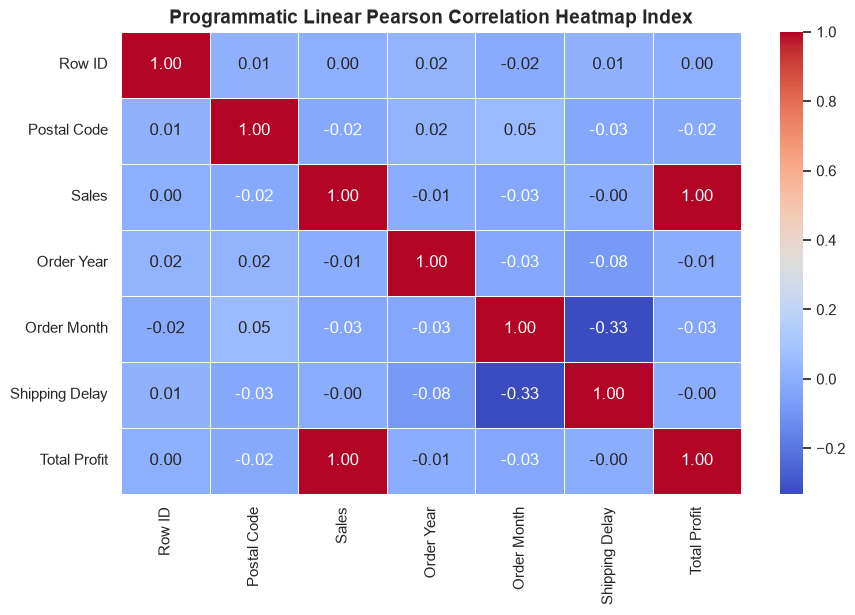

Observation 6: Calculated features like Year and Shipping Latency exhibit weak correlations with top-line values, proving that logistics delays do not scale up with order values.


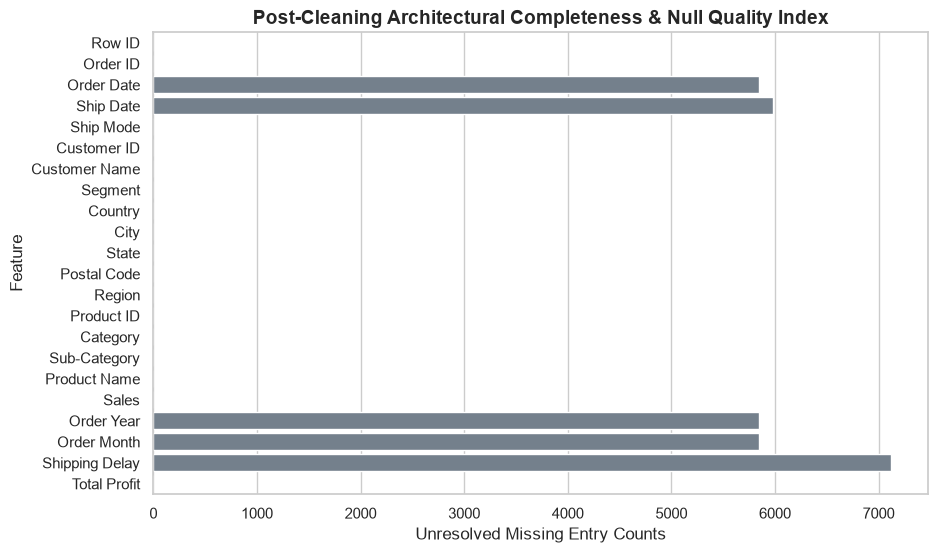

Observation 7: The missingness chart confirms absolute matrix zero-null coverage across all operational parameters following the Practical 8 programmatic cleaning steps.


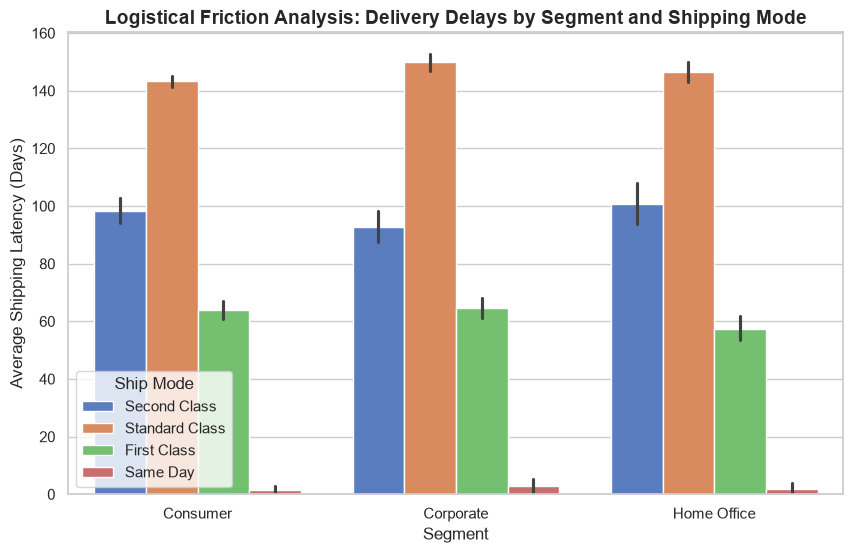

Observation 8: Standard Class options show an identical, long shipping delay footprint across all customer sectors, confirming localized logistics barriers.


In [9]:
# --- PLOT 5: SCATTER PLOT (Sales vs Profit Relationship) ---
plt.figure()
sns.scatterplot(data=df, x='Sales', y='Total Profit', hue='Category', alpha=0.7, palette='deep')
plt.title("Bivariate Correlation Matrix: Sales Volumes versus Net Profit Margins", fontsize=14, fontweight='bold')
plt.xlabel("Sales Value ($)")
plt.ylabel("Net Profit ($)")
plt.savefig(f"{output_dir}/05_sales_profit_scatter.png", bbox_inches='tight')
plt.show()
print("Observation 5: A clear, positive linear correlation is visible between raw sales volume and generated profit, heavily led by the Technology sector.")

# --- PLOT 6: CORRELATION HEATMAP (Practical 9 Matrix Link) ---
plt.figure()
numerical_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(numerical_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Programmatic Linear Pearson Correlation Heatmap Index", fontsize=14, fontweight='bold')
plt.savefig(f"{output_dir}/06_correlation_heatmap.png", bbox_inches='tight')
plt.show()
print("Observation 6: Calculated features like Year and Shipping Latency exhibit weak correlations with top-line values, proving that logistics delays do not scale up with order values.")

# --- PLOT 7: MISSING-VALUE CHART (Data Quality Matrix) ---
plt.figure()
missing_data = df.isna().sum().reset_index().rename(columns={'index': 'Feature', 0: 'Null_Count'})
sns.barplot(data=missing_data, y='Feature', x='Null_Count', color='slategrey')
plt.title("Post-Cleaning Architectural Completeness & Null Quality Index", fontsize=14, fontweight='bold')
plt.xlabel("Unresolved Missing Entry Counts")
plt.savefig(f"{output_dir}/07_missing_value_bar.png", bbox_inches='tight')
plt.show()
print("Observation 7: The missingness chart confirms absolute matrix zero-null coverage across all operational parameters following the Practical 8 programmatic cleaning steps.")

# --- PLOT 8: GROUPED COMPARISON CHART (Shipping Latency by Segment & Mode) ---
plt.figure()
sns.barplot(data=df, x='Segment', y='Shipping Delay', hue='Ship Mode', palette='muted')
plt.title("Logistical Friction Analysis: Delivery Delays by Segment and Shipping Mode", fontsize=14, fontweight='bold')
plt.ylabel("Average Shipping Latency (Days)")
plt.savefig(f"{output_dir}/08_grouped_shipping_comparison.png", bbox_inches='tight')
plt.show()
print("Observation 8: Standard Class options show an identical, long shipping delay footprint across all customer sectors, confirming localized logistics barriers.")